In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from experiments.plotting import _plot_SRE_distribution, view_correlation

from src.utils import configure_logger
from GNN.training.utils import to_scalar
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [4]:
model_type="gnn"
epochs = 40
lr = 1.9e-3
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
model_save_path = f"../outputs/models/final/{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
split = "target"  # "target" | "family"


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 0.0,
}

In [5]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-06-15 10:24:23,653 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=clifford | loss_type=huber
2026-06-15 10:24:23,657 - GNN.training.runners - INFO - Training configuration done.
2026-06-15 10:24:23,657 - GNN.training.runners - INFO - Collecting data paths...
2026-06-15 10:24:23,659 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-15 10:24:23,659 - GNN.training.runners - INFO - Data paths collected.
2026-06-15 10:24:23,660 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-15 10:24:50,629 - GNN.training.runners - INFO - Loaders and model built.
2026-06-15 10:24:50,631 - GNN.training.runners - INFO - Starting training...
2026-06-15 10:24:50,632 - GNN.training.train - INFO - Using device: cuda
2026-06-15 10:24:50,850 - GNN.training.train - INFO - -------- EPOCH 001 --------


2026-06-15 10:25:25,978 - GNN.training.train - INFO - Training complete (35.1s) | running validation...


2026-06-15 10:25:28,868 - GNN.training.train - INFO - Losses | train 0.015554 | val 0.006793 | lr 1.90e-03 | time train=35.1s val=2.9s total=38.0s
2026-06-15 10:25:28,871 - GNN.training.train - INFO - -------- EPOCH 002 --------


2026-06-15 10:26:03,866 - GNN.training.train - INFO - Training complete (35.0s) | running validation...


2026-06-15 10:26:06,698 - GNN.training.train - INFO - Losses | train 0.006647 | val 0.005155 | lr 1.90e-03 | time train=35.0s val=2.8s total=37.8s
2026-06-15 10:26:06,700 - GNN.training.train - INFO - -------- EPOCH 003 --------


...

2026-06-15 10:46:44,214 - GNN.training.train - INFO - Losses | train 0.004473 | val 0.003834 | lr 2.37e-04 | time train=30.2s val=2.5s total=32.7s
2026-06-15 10:46:44,215 - GNN.training.train - INFO - -------- EPOCH 039 --------


2026-06-15 10:47:15,533 - GNN.training.train - INFO - Training complete (31.3s) | running validation...


2026-06-15 10:47:17,930 - GNN.training.train - INFO - Losses | train 0.004408 | val 0.003944 | lr 2.37e-04 | time train=31.3s val=2.4s total=33.7s
2026-06-15 10:47:17,932 - GNN.training.train - INFO - -------- EPOCH 040 --------


2026-06-15 10:47:49,248 - GNN.training.train - INFO - Training complete (31.3s) | running validation...


2026-06-15 10:47:51,751 - GNN.training.train - INFO - Losses | train 0.004410 | val 0.004267 | lr 2.37e-04 | time train=31.3s val=2.5s total=33.8s
2026-06-15 10:48:33,701 - GNN.training.runners - INFO - Training complete.
2026-06-15 10:48:33,828 - GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\final\clifford_model_gnn_per_family.pt
2026-06-15 10:48:33,865 - scripts.train_model - INFO - Final test loss: 0.003673
2026-06-15 10:48:33,867 - scripts.train_model - INFO - Test R2 score: 0.8661
2026-06-15 10:48:33,868 - scripts.train_model - INFO - Validation R2 score: 0.8588
2026-06-15 10:48:33,869 - scripts.train_model - INFO - Training R2 score: 0.8649


In [7]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = f"../outputs/models/final/clifford_model_gnn_per_family.pt"
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-15 10:48:58,617 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/final/clifford_model_gnn_per_family.pt
2026-06-15 10:48:58,630 - scripts.predictions - INFO - Found 1 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [02:26<00:00, 26.61batch/s]
2026-06-15 10:52:05,044 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_clifford.csv
2026-06-15 10:52:05,163 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_clifford.png
2026-06-15 10:52:05,287 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_clifford.png


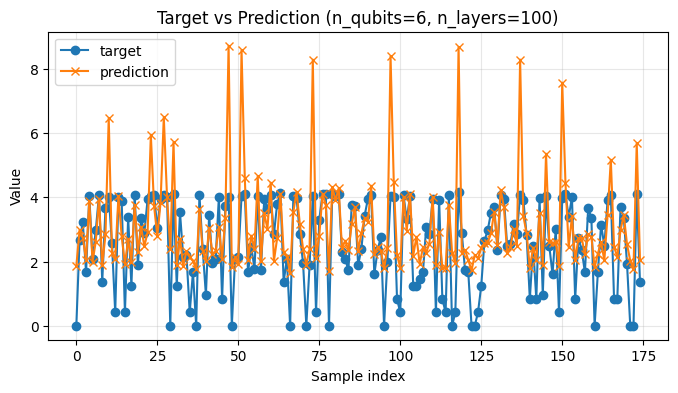

Pearson r = 0.6721


Text(0.5, 1.0, 'True vs Predicted SRE for Quansistor Family (GNN Model)')

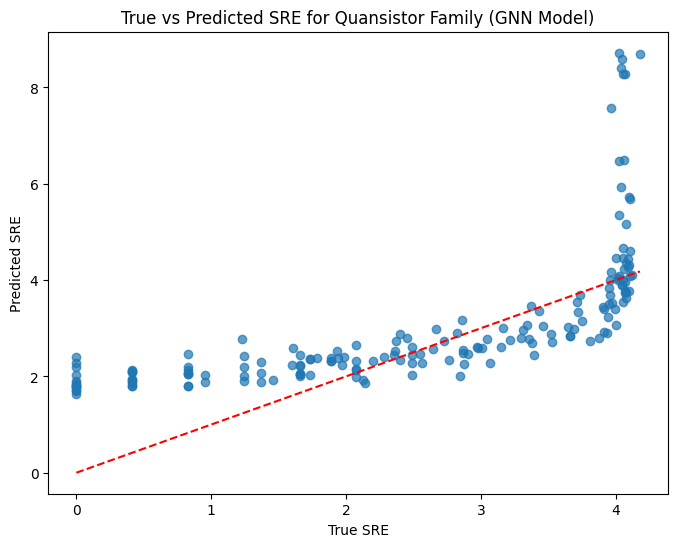

In [ ]:
df = pd.read_csv(f"../outputs/predictions/family/gnn_predictions_clifford.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

nq=plot_qubits
nl=plot_layers
df["prediction"] = df["prediction"] * nq
view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target",
    col_y="prediction",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target"], df["prediction"], alpha=0.7)
plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Quansistor Family (GNN Model)")

### Optuna search

In [ ]:
study_name = f"optuna_search_{model_type}_{training_mode}_{family}_{target}_1"
storage_url = "sqlite:///optuna_studies.db"
n_trials = 15

optuna_search(
    model_type=model_type,
    training_mode=training_mode,
    family=family,
    data_dir=training_data_dir,
    target=target,
    study_name=study_name,
    storage_url=storage_url,
    n_trials=n_trials,
)

2026-06-15 10:52:42,420 - scripts.optuna_search - INFO - Starting Optuna hyperparameter search...
2026-06-15 10:52:42,422 - scripts.optuna_search - INFO - Found 1 dataset files for target=sre in data_dir=../outputs/data/datasets_SRE.
2026-06-15 10:53:06,906 - scripts.optuna_search - INFO - Prepared datasets with loader_kind=gnn. Starting Optuna study with name='optuna_search_gnn_per_family_clifford_sre_1' and storage='sqlite:///optuna_studies.db'...
[I 2026-06-15 10:53:08,053] A new study created in RDB with name: optuna_search_gnn_per_family_clifford_sre_1
2026-06-15 10:53:08,056 - scripts.optuna_search - INFO - Running Optuna optimization for 15 trials...
2026-06-15 10:53:08,145 - GNN.training.train - INFO - Using device: cuda
2026-06-15 10:53:08,148 - GNN.training.train - INFO - -------- EPOCH 001 --------
2026-06-15 10:53:34,841 - GNN.training.train - INFO - Training complete (26.7s) | running validation...
2026-06-15 10:53:37,252 - GNN.training.train - INFO - Losses | train 0.0351